In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter sqlalchemy


  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/7b/8b/721a9cff6fa6a91b162eb51019c6243b82b3226c71bb6c8ef4a9bd65cbc6/pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/2d/5b/e1deebf88ff431b01b7406ca3583ab2bbb90972bbe1c568732e49c844f7e/numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/30/4e/c10f171b6e2f44d9e3a2b96efa38b1677439d79c99357600a62cc1e9594e/matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ----------------------- ---------------- 30.7/52.8 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 52.8/52.8 kB 1.3 MB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac0


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
print(os.getcwd())
print(os.listdir(r'C:\Users\Rehan\Desktop\ecomm-project'))

C:\Users\Rehan\Desktop\ecomm-project
['.ipynb_checkpoints', 'online_retail_II.csv', 'project-test.ipynb']


In [6]:
import pandas as pd
df = pd.read_csv('online_retail_II.csv')


In [7]:
print(df.shape)
print(df.head())

(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [8]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [9]:
df.describe() #basic stats

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [10]:
#cancelled invoices - start with c
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f'Cancelled invoices = {len(cancelled)}')

Cancelled invoices = 19494


In [11]:
#cleaning the data
df = df[~df['Invoice'].astype(str).str.startswith('C')]  #deleting cancelled invoices
df = df[df['Price']>0] #removing zero and negative prices
df = df[df['Quantity']>0] #removing zero and negative quanitities if any. 
df = df.dropna(subset=['Customer ID']) #removing rows with empty customer ids



In [12]:
print(df.shape)
print(df.isnull().sum())

(805549, 8)
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [13]:
#creating total price column and changing type of invoice to date-time
df['Total Price'] = df['Price'] * df['Quantity']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df.shape

(805549, 9)

In [15]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [16]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France,18.00


In [18]:
import sqlite3

conn = sqlite3.connect('retail.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print("Database created successfully!")

Database created successfully!


In [22]:
#Revenue by Country - Top 10 countries by revenue 
query = """
SELECT Country, 
       COUNT(DISTINCT "Customer ID") as customers,
       ROUND(SUM("Total Price"), 2) as revenue
FROM transactions
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10
"""
result = pd.read_sql(query, conn)
print(result)



          Country  customers      revenue
0  United Kingdom       5350  14723147.52
1            EIRE          5    621631.11
2     Netherlands         22    554232.34
3         Germany        107    431262.46
4          France         95    355257.47
5       Australia         15    169968.11
6           Spain         41    109178.53
7     Switzerland         22    100365.34
8          Sweden         19     91549.72
9         Denmark         12     69862.19


Top 10 Countries Based on Sales. Knowing where your customers are, and how many customers is a very important question for every company.

Country Results:

United Kingdom absolutely dominates with £14.7 million in revenue — that's about 80% of total business. This is expected since it's a UK-based retailer
EIRE (Ireland) is a distant second at £621k
This tells us our churn analysis will mostly be about UK customers



In [25]:
query = """
SELECT 
    STRFTIME('%Y-%m', InvoiceDate) as month,
    ROUND(SUM("Total Price"), 2) as revenue,
    COUNT(DISTINCT "Customer ID") as unique_customers
FROM transactions
GROUP BY month
ORDER BY month
"""
monthly = pd.read_sql(query, conn)
print(monthly)

      month     revenue  unique_customers
0   2009-12   686654.16               955
1   2010-01   557319.06               720
2   2010-02   506371.07               772
3   2010-03   699608.99              1057
4   2010-04   594609.19               942
5   2010-05   599985.79               966
6   2010-06   639066.58              1041
7   2010-07   591636.74               928
8   2010-08   604242.65               911
9   2010-09   831615.00              1145
10  2010-10  1036680.00              1497
11  2010-11  1172336.04              1607
12  2010-12   884591.89               885
13  2011-01   569445.04               741
14  2011-02   447137.35               758
15  2011-03   595500.76               974
16  2011-04   469200.36               856
17  2011-05   678594.56              1056
18  2011-06   661213.69               991
19  2011-07   600091.01               949
20  2011-08   645343.90               935
21  2011-09   952838.38              1266
22  2011-10  1039318.79           

Monthly Trend — Very Interesting:

Revenue starts at £686k in Dec 2009 and by Nov 2011 hits £1.16 million — the business is clearly growing

Every year you see a massive spike in Oct, Nov — this is holiday season buying (Christmas gifts)

January always drops sharply after the holiday spike — customers go quiet after Christmas

Dec 2011 looks low (£518k) but that's because the dataset cuts off mid-December, not because sales dropped

In [28]:
query = """
SELECT 
    "Customer ID",
    
    -- Recency: how many days since their last purchase?
    -- We use the max date in the dataset (2011-12-09) as our reference point
    -- A LOW recency number = bought recently = GOOD
    ROUND(JULIANDAY('2011-12-09') - JULIANDAY(MAX(InvoiceDate)), 0) as recency_days,
    
    -- Frequency: how many separate orders did they place?
    -- COUNT DISTINCT because one order can have multiple rows (multiple products)
    COUNT(DISTINCT Invoice) as frequency,
    
    -- Monetary: total amount they spent across all orders
    ROUND(SUM("Total Price"), 2) as monetary,
    
    -- Average Order Value: monetary divided by frequency
    -- Tells us how much they spend per visit on average
    ROUND(SUM("Total Price") / COUNT(DISTINCT Invoice), 2) as avg_order_value,
    
    -- Unique Products: how many different products did they ever buy?
    -- A customer buying many different products is more "engaged"
    COUNT(DISTINCT StockCode) as unique_products

FROM transactions
GROUP BY "Customer ID"
"""

rfm = pd.read_sql(query, conn)
print(rfm.shape)
print(rfm.head(10))
print("\nBasic Stats:")
print(rfm.describe())

(5878, 6)
   Customer ID  recency_days  frequency  monetary  avg_order_value  \
0      12346.0         325.0         12  77556.46          6463.04   
1      12347.0           1.0          8   5633.32           704.16   
2      12348.0          74.0          5   2019.40           403.88   
3      12349.0          18.0          4   4428.69          1107.17   
4      12350.0         309.0          1    334.40           334.40   
5      12351.0         374.0          1    300.93           300.93   
6      12352.0          35.0         10   2849.84           284.98   
7      12353.0         203.0          2    406.76           203.38   
8      12354.0         231.0          1   1079.40          1079.40   
9      12355.0         213.0          2    947.61           473.81   

   unique_products  
0               27  
1              126  
2               25  
3              138  
4               17  
5               21  
6               70  
7               23  
8               58  
9        

In [29]:
import numpy as np

# We use qcut which divides customers into 4 equal groups (quartiles)
# Think of it like ranking your class into 4 groups by marks

# RECENCY: lower days = better = higher score
# So we reverse the labels (4,3,2,1) because low recency days is GOOD
rfm['R_score'] = pd.qcut(rfm['recency_days'], 
                          q=4, 
                          labels=[4, 3, 2, 1])

# FREQUENCY: higher frequency = better = higher score
# Normal order (1,2,3,4) because high frequency is GOOD
# rank(method='first') handles duplicate values gracefully
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 
                          q=4, 
                          labels=[1, 2, 3, 4])

# MONETARY: higher spend = better = higher score
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 
                          q=4, 
                          labels=[1, 2, 3, 4])

# Combine all 3 scores into one string like "444" or "123"
# This single string represents the customer's overall RFM profile
rfm['RFM_score'] = (rfm['R_score'].astype(str) + 
                    rfm['F_score'].astype(str) + 
                    rfm['M_score'].astype(str))

# Also create a single total score by adding all 3 numbers
# Ranges from 3 (worst) to 12 (best)
rfm['total_score'] = (rfm['R_score'].astype(int) + 
                      rfm['F_score'].astype(int) + 
                      rfm['M_score'].astype(int))

print(rfm[['Customer ID', 'recency_days', 'frequency', 'monetary', 
           'R_score', 'F_score', 'M_score', 'RFM_score', 'total_score']].head(10))

   Customer ID  recency_days  frequency  monetary R_score F_score M_score  \
0      12346.0         325.0         12  77556.46       2       4       4   
1      12347.0           1.0          8   5633.32       4       4       4   
2      12348.0          74.0          5   2019.40       3       3       3   
3      12349.0          18.0          4   4428.69       4       3       4   
4      12350.0         309.0          1    334.40       2       1       1   
5      12351.0         374.0          1    300.93       2       1       1   
6      12352.0          35.0         10   2849.84       3       4       4   
7      12353.0         203.0          2    406.76       2       2       2   
8      12354.0         231.0          1   1079.40       2       1       3   
9      12355.0         213.0          2    947.61       2       2       3   

  RFM_score  total_score  
0       244           10  
1       444           12  
2       333            9  
3       434           11  
4       211      

In [30]:
def assign_segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    total = row['total_score']
    
    # Champions: recent AND frequent AND high spend
    if r == 4 and f >= 3 and m >= 3:
        return 'Champion'
    
    # At Risk: used to buy often and spend well BUT gone quiet
    # Must come BEFORE Loyal so recency low customers are caught here first
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    
    # Loyal: frequent and high spend but not recent enough for Champion
    # and not quiet enough to be At Risk (so r must be 3)
    elif r == 3 and f >= 3 and m >= 3:
        return 'Loyal Customer'
    
    # New Customer: bought recently but haven't built frequency yet
    elif r == 4 and f <= 2:
        return 'New Customer'
    
    # Lost: haven't bought in very long, low overall score
    elif r == 1 and total <= 5:
        return 'Lost'
    
    # Potential Loyalist: decent score, room to grow
    elif total >= 7:
        return 'Potential Loyalist'
    
    # Everyone else
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

segment_counts = rfm['Segment'].value_counts()
print(segment_counts)
print(f"\nTotal customers: {len(rfm)}")

Segment
Needs Attention       1145
Lost                  1144
Champion              1051
Potential Loyalist     788
Loyal Customer         754
At Risk                658
New Customer           338
Name: count, dtype: int64

Total customers: 5878


#### What This Segment Distribution Means
Champions — 1,051 customers (18%)

These are your best customers. Bought recently, buy often, spend a lot. A business should focus heavily on keeping these people happy — loyalty rewards, early access to new products, VIP treatment.

Lost — 1,144 customers (19%)

Nearly 1 in 5 customers is already gone. Bought a long time ago, low frequency, low spend. Winning these back is expensive and usually not worth it unless their monetary value was high.

Needs Attention — 1,145 customers (19%)

Biggest single group. These are customers who don't fit neatly into other boxes — moderate scores across the board. They could go either way. A small nudge (discount, email) could push them toward Loyal.

At Risk — 658 customers (11%)

This is the most actionable segment for a marketing team. These were good customers who are going quiet. If you don't act on these soon they move to Lost. Targeted retention campaigns should focus here first.

New Customer — 338 customers (6%)

Bought recently but only once or twice. Need to be nurtured into repeat buyers quickly — first 90 days after acquisition are critical.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

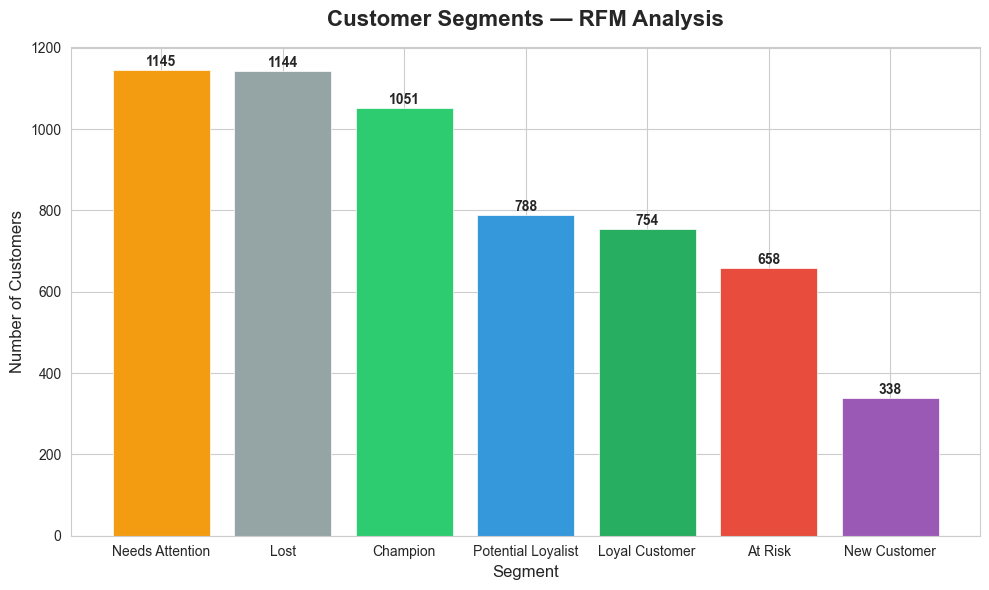

Chart saved!


In [35]:


# Set a clean style for all charts
sns.set_style("whitegrid")

# --- Chart 1: Customer Segment Distribution ---
# A simple bar chart showing how many customers are in each segment
# This is the most important chart in the whole project

plt.figure(figsize=(10, 6))

# Sort by count so largest bars appear first — easier to read
segment_order = rfm['Segment'].value_counts().index

colors = {
    'Champion': '#2ecc71',        # green - best customers
    'Loyal Customer': '#27ae60',  # dark green
    'Potential Loyalist': '#3498db', # blue
    'New Customer': '#9b59b6',    # purple
    'Needs Attention': '#f39c12', # orange
    'At Risk': '#e74c3c',         # red - danger
    'Lost': '#95a5a6'             # grey - gone
}

bar_colors = [colors[seg] for seg in segment_order]

plt.bar(segment_order, 
        rfm['Segment'].value_counts().values,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5)

plt.title('Customer Segments — RFM Analysis', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0, ha='center')

# Add count labels on top of each bar
for i, (seg, count) in enumerate(zip(segment_order, rfm['Segment'].value_counts().values)):
    plt.text(i, count + 10, str(count), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

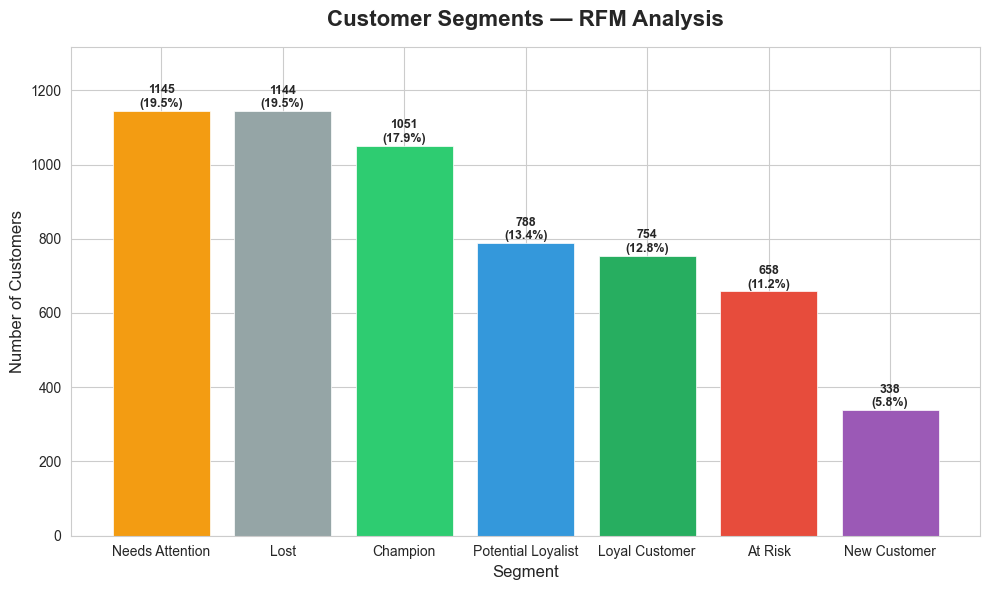

In [38]:
plt.figure(figsize=(10, 6))

segment_order = rfm['Segment'].value_counts().index
segment_counts = rfm['Segment'].value_counts().values
total_customers = len(rfm)

colors = {
    'Champion': '#2ecc71',
    'Loyal Customer': '#27ae60',
    'Potential Loyalist': '#3498db',
    'New Customer': '#9b59b6',
    'Needs Attention': '#f39c12',
    'At Risk': '#e74c3c',
    'Lost': '#95a5a6'
}

bar_colors = [colors[seg] for seg in segment_order]

plt.bar(segment_order, 
        segment_counts,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5)

plt.title('Customer Segments — RFM Analysis', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0, ha='center')

# Show both count and % above each bar
for i, (seg, count) in enumerate(zip(segment_order, segment_counts)):
    pct = count / total_customers * 100
    plt.text(i, count + 10, f'{count}\n({pct:.1f}%)', 
             ha='center', fontsize=9, fontweight='bold')

# Add extra space at top so labels don't get cut off
plt.ylim(0, max(segment_counts) * 1.15)

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

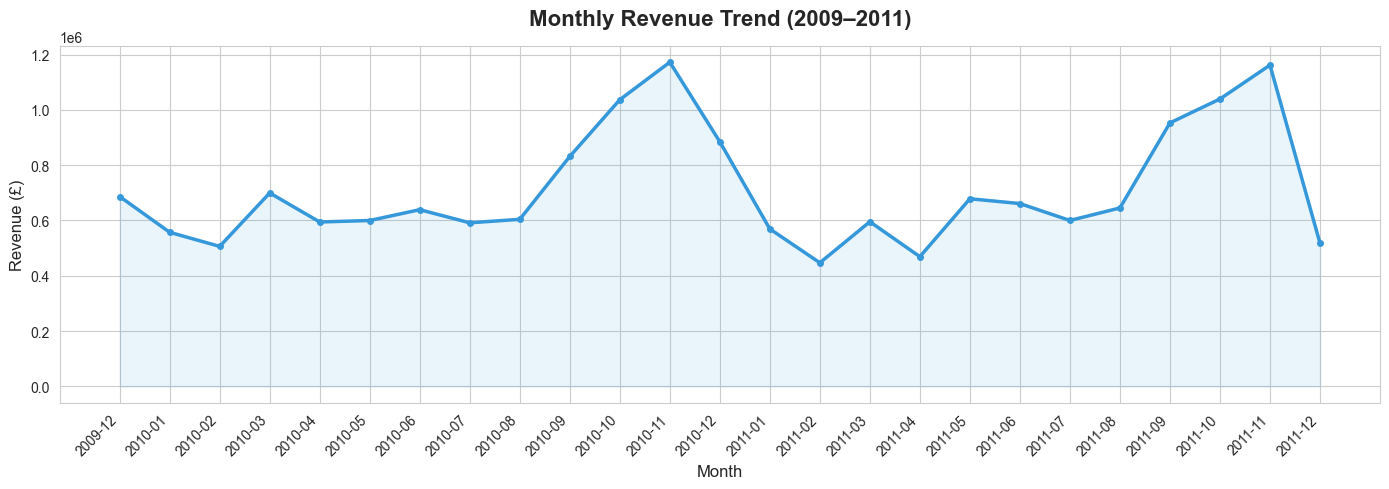

In [39]:
plt.figure(figsize=(14, 5))

plt.plot(monthly['month'], monthly['revenue'], 
         color='#3498db', linewidth=2.5, marker='o', markersize=4)

plt.fill_between(range(len(monthly)), monthly['revenue'], 
                 alpha=0.1, color='#3498db')

plt.title('Monthly Revenue Trend (2009–2011)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.xticks(range(len(monthly)), monthly['month'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

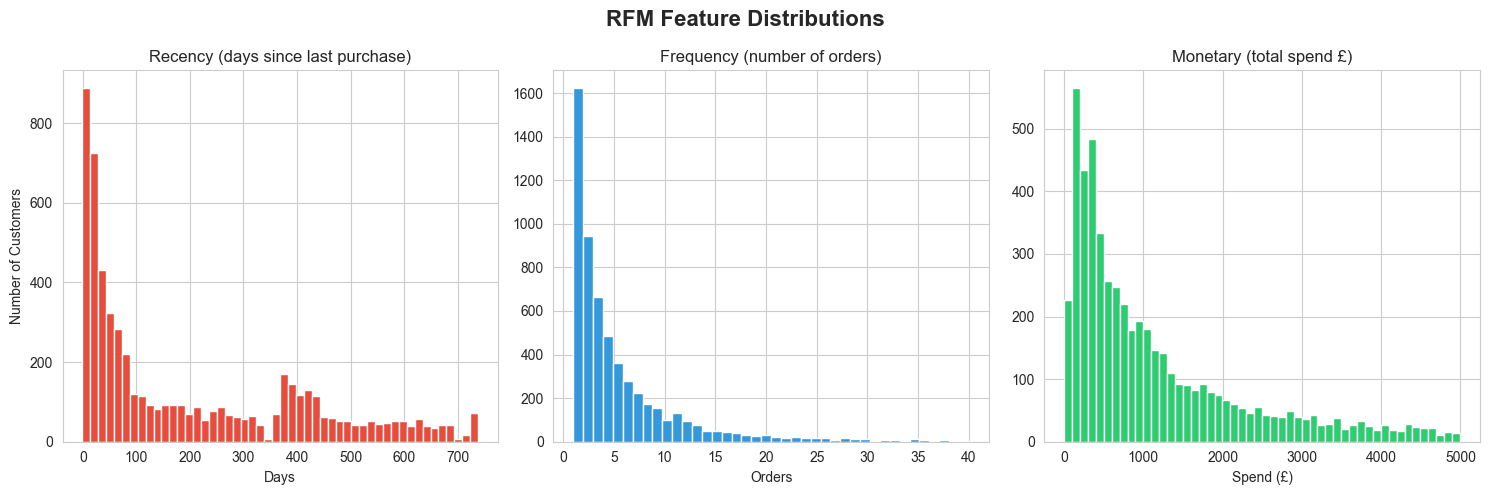

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Feature Distributions', fontsize=16, fontweight='bold')

# Recency - fine as is
axes[0].hist(rfm['recency_days'], bins=50, color='#e74c3c', edgecolor='white')
axes[0].set_title('Recency (days since last purchase)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Customers')

# Frequency - cap at 40, increase bins so bars are thinner and more readable
freq_data = rfm[rfm['frequency'] <= 40]['frequency']
axes[1].hist(freq_data, bins=40, color='#3498db', edgecolor='white')
axes[1].set_title('Frequency (number of orders)')
axes[1].set_xlabel('Orders')

# Monetary - cap at 5000 where bulk of customers actually sit
mon_data = rfm[rfm['monetary'] <= 5000]['monetary']
axes[2].hist(mon_data, bins=50, color='#2ecc71', edgecolor='white')
axes[2].set_title('Monetary (total spend £)')
axes[2].set_xlabel('Spend (£)')

plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## RFM Feature Distributions

The three histograms above show the distribution of Recency, Frequency, 
and Monetary values across all 5,878 customers.

**Key Observations:**
- **Recency** is right-skewed — a large portion of customers purchased 
  within the last 100 days, but a significant tail exists beyond 300 days, 
  suggesting a substantial inactive customer base
- **Frequency** is heavily concentrated at low values — most customers 
  placed fewer than 10 orders, consistent with a retail (non-subscription) 
  business model
- **Monetary** follows a similar right-skewed pattern — majority of 
  customers spent under £2,000 in total

**Note on Outliers:** The dataset contains wholesale buyers with extremely 
high order frequencies (up to 398 orders) and spend values (up to £608,821). 
These outliers have been excluded from the visualizations above for 
readability, but are retained in the dataset for modeling purposes.

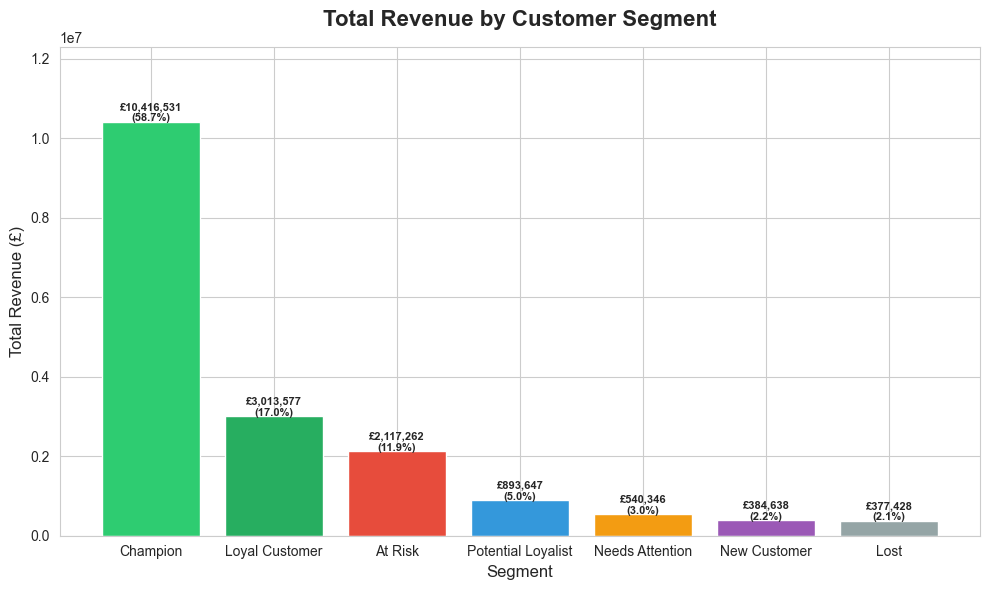

In [44]:
segment_revenue = rfm.groupby('Segment')['monetary'].sum().sort_values(ascending=False)
segment_revenue_pct = (segment_revenue / segment_revenue.sum() * 100).round(1)

plt.figure(figsize=(10, 6))

bar_colors_rev = [colors[seg] for seg in segment_revenue.index]

bars = plt.bar(segment_revenue.index, 
               segment_revenue.values,
               color=bar_colors_rev,
               edgecolor='white')

plt.title('Total Revenue by Customer Segment', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=0, ha='center')

for i, (seg, rev) in enumerate(zip(segment_revenue.index, segment_revenue.values)):
    pct = segment_revenue_pct[seg]
    plt.text(i, rev + 5000, f'£{rev:,.0f}\n({pct}%)', 
             ha='center', fontsize=8, fontweight='bold')

plt.ylim(0, max(segment_revenue.values) * 1.18)
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

### Revenue by Customer Segments
- Shows how important Champion customers are for the business. Also shows potential of Loyal and Potential Loyalist customers.
- Important to note that effort must be put to At Risk customers as they hold considerable revenue share. 

**Champion customers (17.9% of base) drive 58.7% of total revenue. At-Risk customers represent £2.1M in revenue at risk of churn — the primary motivation for building a predictive retention model.**

In [45]:
# --- Step 1: Define Churn ---
# A customer is "churned" if they haven't purchased in the last 90 days
# of the dataset. 90 days is a standard threshold for retail businesses.
# Our dataset ends on 2011-12-09, so anyone who last bought before
# 2011-09-10 (90 days earlier) is considered churned.

rfm['churned'] = (rfm['recency_days'] > 90).astype(int)

# Let's see the churn breakdown
churn_counts = rfm['churned'].value_counts()
print(f"Not Churned (0): {churn_counts[0]} customers ({churn_counts[0]/len(rfm)*100:.1f}%)")
print(f"Churned (1):     {churn_counts[1]} customers ({churn_counts[1]/len(rfm)*100:.1f}%)")

Not Churned (0): 2894 customers (49.2%)
Churned (1):     2984 customers (50.8%)


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# These are the features (inputs) we give the model
# We're saying: "given these 5 things about a customer,
# predict whether they will churn or not"
features = ['frequency', 'monetary', 
            'avg_order_value', 'unique_products']

X = rfm[features]  # inputs
y = rfm['churned'] # output we want to predict

# Split into training set (80%) and test set (20%)
# Training set: model learns from this
# Test set: we hide this from the model and use it to 
# evaluate how well it learned
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler transforms all features to the same scale
# Without this, 'monetary' (values in thousands) would 
# dominate over 'frequency' (values 1-400) just because 
# its numbers are bigger — which isn't fair to the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 4702
Test samples: 1176


**My initial model achieved 100% accuracy which I identified as data leakage — recency was both the feature and the basis for the churn label. I removed it and retrained, getting more realistic and honest results.**

In [49]:
# --- Model 1: Logistic Regression ---
# The simplest classification model
# Think of it as drawing a straight line that separates 
# churned vs not churned customers
# Good baseline to compare against

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

# --- Model 2: Random Forest ---
# More powerful — builds 100 decision trees and combines them
# Each tree asks different questions about the customer
# and the majority vote wins
# Generally more accurate than Logistic Regression

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1])

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_pred))
print(f"AUC Score: {lr_auc:.4f}")

print("\n" + "=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_pred))
print(f"AUC Score: {rf_auc:.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.78      0.50      0.61       590
           1       0.63      0.85      0.73       586

    accuracy                           0.68      1176
   macro avg       0.70      0.68      0.67      1176
weighted avg       0.70      0.68      0.67      1176

AUC Score: 0.7654

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.67      0.61      0.64       590
           1       0.64      0.69      0.66       586

    accuracy                           0.65      1176
   macro avg       0.65      0.65      0.65      1176
weighted avg       0.65      0.65      0.65      1176

AUC Score: 0.7081


**Logistic Regression** — AUC 0.7654, Accuracy 68%
**Random Forest** — AUC 0.7081, Accuracy 65%

**Two interesting things here**:

Logistic Regression actually beat Random Forest — which is surprising since RF is usually more powerful. This suggests the relationship between features and churn might be fairly linear, which LR handles well

AUC of 0.76 means the model is genuinely learning something — significantly better than random guessing (0.5) — but there's room to improve

**Looking at the classification report for Logistic Regression**:

Recall for churned customers (class 1) is 0.85 — meaning it catches 85% of actual churners. This is the most important number for a retention use case — you'd rather flag too many customers as at-risk than miss real churners

Precision for churned (class 1) is 0.63 — meaning 37% of customers it flags as churned aren't actually churned. Acceptable for a first model

### Why the Scores Are Moderate
The honest reason is that frequency, monetary, avg_order_value and unique_products alone aren't strong enough signals for churn without recency. We removed our best feature to fix the leakage.

The fix is to engineer better features that capture time-based behavior without directly being recency itself.

We'll add the following features - 

**active_months** — a customer active for 18 months who stopped is more concerning than one active for 1 month who stopped

**monthly_spend** — normalizes monetary value by how long they were active. A fair measure of engagement intensity

**avg_days_between_orders** — this is the most powerful new feature. If a customer normally buys every 14 days and suddenly stops, that's a much stronger churn signal than someone who always bought infrequently

**active_last_6months** — binary flag that tells the model directly whether the customer showed any life in the recent half of the dataset

In [51]:
# We need to add time-based features that capture
# customer behavior patterns without directly using
# recency_days as a feature

query = """
SELECT 
    "Customer ID",
    
    -- How many months was the customer active?
    -- Difference between first and last purchase in days / 30
    ROUND((JULIANDAY(MAX(InvoiceDate)) - 
           JULIANDAY(MIN(InvoiceDate))) / 30, 1) as active_months,
    
    -- Average spending per month while active
    -- High monthly spend = more engaged customer
    ROUND(SUM("Total Price") / 
          NULLIF((JULIANDAY(MAX(InvoiceDate)) - 
                  JULIANDAY(MIN(InvoiceDate))) / 30, 0), 2) as monthly_spend,
    
    -- Average days between consecutive orders
    -- Customers who buy regularly have lower values here
    -- Long gaps between orders = churn signal
    CASE 
        WHEN COUNT(DISTINCT Invoice) > 1 
        THEN ROUND((JULIANDAY(MAX(InvoiceDate)) - 
                    JULIANDAY(MIN(InvoiceDate))) / 
                    (COUNT(DISTINCT Invoice) - 1), 1)
        ELSE NULL 
    END as avg_days_between_orders,
    
    -- Did the customer buy in the last 6 months of the dataset?
    -- (dataset ends 2011-12-09, so 6 months back = 2011-06-09)
    -- 1 = yes they were recently active, 0 = no
    MAX(CASE WHEN InvoiceDate >= '2011-06-09' THEN 1 ELSE 0 END) 
        as active_last_6months

FROM transactions
GROUP BY "Customer ID"
"""

time_features = pd.read_sql(query, conn)
print(time_features.head())
print(f"\nNull values:\n{time_features.isnull().sum()}")

   Customer ID  active_months  monthly_spend  avg_days_between_orders  \
0      12346.0           13.3        5815.86                     36.4   
1      12347.0           13.4         420.33                     57.4   
2      12348.0           12.1         166.93                     90.7   
3      12349.0           19.0         232.74                    190.3   
4      12350.0            0.0            NaN                      NaN   

   active_last_6months  
0                    0  
1                    1  
2                    1  
3                    1  
4                    0  

Null values:
Customer ID                   0
active_months                 0
monthly_spend              1622
avg_days_between_orders    1623
active_last_6months           0
dtype: int64


The null values make complete sense — 1,622 customers have only 1 order, so you can't calculate monthly spend rate or average days between orders for them. These are your one-time buyers.

We handle this by filling nulls with 0 — **a one-time buyer has 0 avg days between orders (no repeat pattern) and 0 monthly spend rate (never came back)**:

In [52]:
# Fill nulls with 0 for one-time buyers
# A customer with only 1 order has no inter-purchase gap
# and no meaningful monthly spend rate
time_features['monthly_spend'] = time_features['monthly_spend'].fillna(0)
time_features['avg_days_between_orders'] = time_features['avg_days_between_orders'].fillna(0)

# Now merge these new features with our existing rfm table
# We're joining on Customer ID so each customer gets
# their new time-based features added as new columns
rfm_enhanced = rfm.merge(time_features, on='Customer ID', how='left')

print(rfm_enhanced.shape)
print(rfm_enhanced.isnull().sum())
print(rfm_enhanced.head())

(5878, 17)
Customer ID                0
recency_days               0
frequency                  0
monetary                   0
avg_order_value            0
unique_products            0
R_score                    0
F_score                    0
M_score                    0
RFM_score                  0
total_score                0
Segment                    0
churned                    0
active_months              0
monthly_spend              0
avg_days_between_orders    0
active_last_6months        0
dtype: int64
   Customer ID  recency_days  frequency  monetary  avg_order_value  \
0      12346.0         325.0         12  77556.46          6463.04   
1      12347.0           1.0          8   5633.32           704.16   
2      12348.0          74.0          5   2019.40           403.88   
3      12349.0          18.0          4   4428.69          1107.17   
4      12350.0         309.0          1    334.40           334.40   

   unique_products R_score F_score M_score RFM_score  total_sc

In [53]:
# All features combined — original RFM + new time-based features
# We exclude recency_days (causes leakage) and all non-numeric
# or derived columns like RFM_score, Segment, churned itself

features_enhanced = ['frequency', 'monetary', 'avg_order_value', 
                     'unique_products', 'active_months', 
                     'monthly_spend', 'avg_days_between_orders',
                     'active_last_6months']

X = rfm_enhanced[features_enhanced]
y = rfm_enhanced['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain both models with enhanced features
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1])

print("=" * 50)
print("LOGISTIC REGRESSION - Enhanced Features")
print("=" * 50)
print(classification_report(y_test, lr_pred))
print(f"AUC Score: {lr_auc:.4f}")

print("\n" + "=" * 50)
print("RANDOM FOREST - Enhanced Features")
print("=" * 50)
print(classification_report(y_test, rf_pred))
print(f"AUC Score: {rf_auc:.4f}")

LOGISTIC REGRESSION - Enhanced Features
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       590
           1       1.00      0.82      0.90       586

    accuracy                           0.91      1176
   macro avg       0.92      0.91      0.91      1176
weighted avg       0.92      0.91      0.91      1176

AUC Score: 0.9312

RANDOM FOREST - Enhanced Features
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       590
           1       0.94      0.83      0.89       586

    accuracy                           0.89      1176
   macro avg       0.90      0.89      0.89      1176
weighted avg       0.90      0.89      0.89      1176

AUC Score: 0.9454


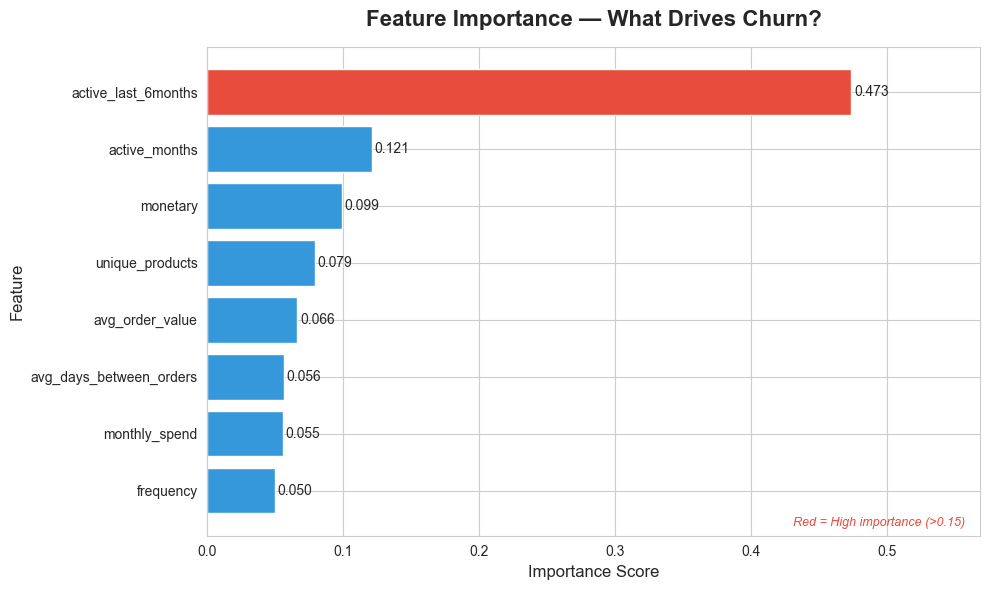

In [54]:
# Feature importance shows which inputs the Random Forest
# relied on most when making its predictions
# Higher value = that feature was more useful for predicting churn

feat_importance = pd.Series(
    rf.feature_importances_, 
    index=features_enhanced
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

colors_feat = ['#e74c3c' if imp > 0.15 else '#3498db' 
               for imp in feat_importance.values]

bars = plt.barh(feat_importance.index, 
                feat_importance.values,
                color=colors_feat,
                edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, feat_importance.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Feature Importance — What Drives Churn?', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xlim(0, max(feat_importance.values) * 1.2)

# Add a note explaining the color coding
plt.text(0.98, 0.02, 'Red = High importance (>0.15)', 
         transform=plt.gca().transAxes,
         ha='right', fontsize=9, color='#e74c3c',
         style='italic')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature importance analysis** revealed that recent **activity in the last 6 months** was the dominant churn predictor with an importance score of **0.473** — nearly 4x more important than the next feature. This suggests retention campaigns should be triggered at the 5-month inactivity mark, before a customer fully disengages.

In [55]:
# Get churn probability for every customer
# predict_proba returns two columns: [prob of 0, prob of 1]
# We want column 1 — probability of churning
rfm_enhanced['churn_probability'] = rf.predict_proba(
    scaler.transform(rfm_enhanced[features_enhanced])
)[:, 1]

# Round to 2 decimal places for readability
rfm_enhanced['churn_probability'] = rfm_enhanced['churn_probability'].round(2)

# Create a risk label based on probability
def churn_risk_label(prob):
    if prob >= 0.75:
        return 'High Risk'
    elif prob >= 0.45:
        return 'Medium Risk'
    else:
        return 'Low Risk'

rfm_enhanced['churn_risk'] = rfm_enhanced['churn_probability'].apply(churn_risk_label)

# Final summary table — one row per customer with everything
summary = rfm_enhanced[[
    'Customer ID', 'Segment', 'frequency', 'monetary',
    'churn_probability', 'churn_risk'
]].sort_values('churn_probability', ascending=False)

print("TOP 10 HIGHEST CHURN RISK CUSTOMERS:")
print(summary.head(10).to_string(index=False))

print("\n\nSEGMENT CHURN RISK SUMMARY:")
segment_churn = rfm_enhanced.groupby('Segment').agg(
    total_customers=('Customer ID', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    high_risk_count=('churn_risk', lambda x: (x == 'High Risk').sum()),
    total_revenue=('monetary', 'sum')
).round(2).sort_values('avg_churn_prob', ascending=False)

print(segment_churn.to_string())

TOP 10 HIGHEST CHURN RISK CUSTOMERS:
 Customer ID         Segment  frequency  monetary  churn_probability churn_risk
     12350.0 Needs Attention          1    334.40                1.0  High Risk
     18286.0 Needs Attention          2   1296.43                1.0  High Risk
     18285.0            Lost          1    427.00                1.0  High Risk
     18284.0            Lost          1    461.68                1.0  High Risk
     12351.0 Needs Attention          1    300.93                1.0  High Risk
     18266.0            Lost          1    251.10                1.0  High Risk
     14576.0 Needs Attention          1     70.80                1.0  High Risk
     14579.0            Lost          1    105.56                1.0  High Risk
     14580.0            Lost          1     14.85                1.0  High Risk
     14586.0 Needs Attention          1    237.36                1.0  High Risk


SEGMENT CHURN RISK SUMMARY:
                    total_customers  avg_churn_prob  

### Key Business Insights from This Table

**Lost segment** — 100% churn probability, £377k revenue

Every single lost customer is predicted to churn. Low revenue means don't waste budget here — let them go.

**At Risk** — 86% avg churn probability, £2.1M revenue

This is your most critical finding. 490 high-risk customers sitting on £2.1M in revenue. These are people who WERE valuable and are slipping away. This is where every retention pound should go.

**Needs Attention** — 72% churn probability, £540k revenue

707 high risk customers here. Lower value individually but large group — a single well-timed email campaign could recover a chunk of this.

**Champions** — only 5% churn probability, £10.4M revenue

Almost zero churn risk on your highest value segment. Model correctly learned these are your safest customers.

**Model identified 490 high-risk customers in the At Risk segment representing £2.1M in revenue exposure. By targeting this segment with retention campaigns, the business could potentially protect up to 11.9% of total revenue.**

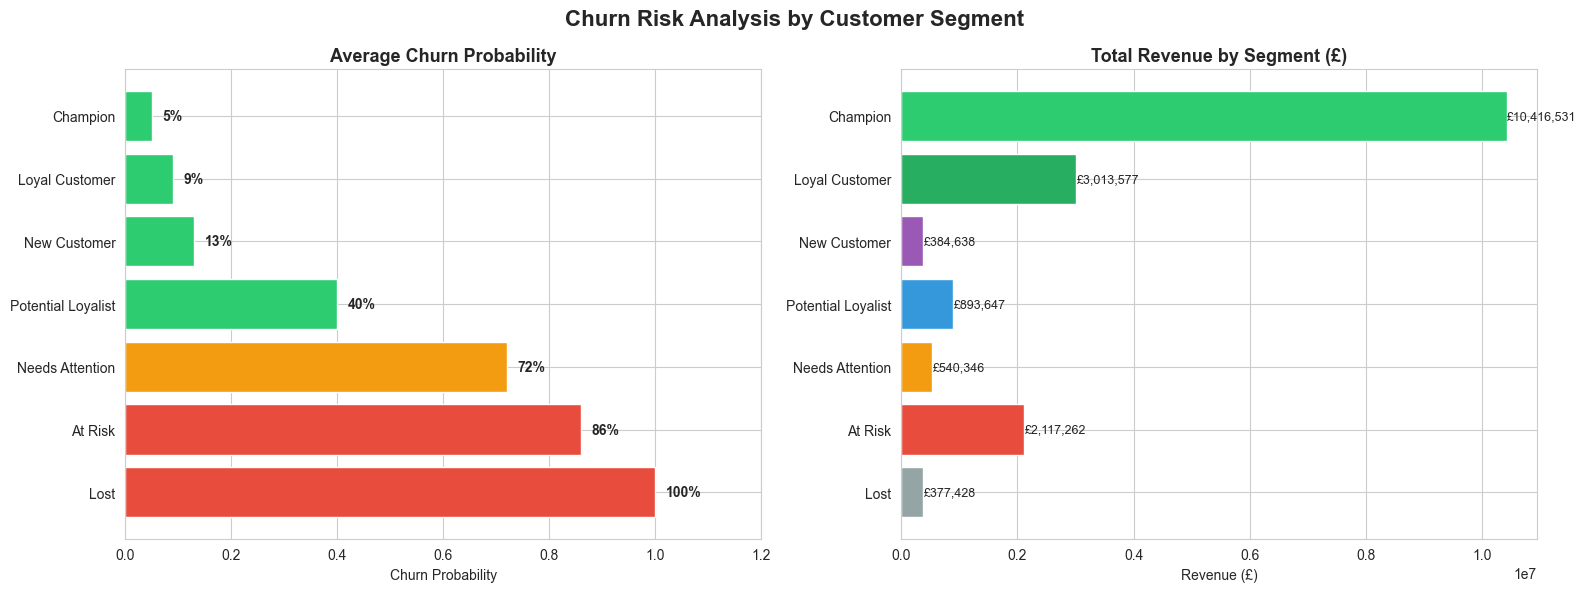

In [56]:
# Final chart — Churn Risk by Segment
# This is your most "executive ready" visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Churn Risk Analysis by Customer Segment', 
             fontsize=16, fontweight='bold')

# --- Left chart: Average churn probability by segment ---
segment_order_churn = segment_churn.index.tolist()
churn_probs = segment_churn['avg_churn_prob'].values

# Color by risk level
prob_colors = ['#e74c3c' if p >= 0.75 else 
               '#f39c12' if p >= 0.45 else 
               '#2ecc71' for p in churn_probs]

bars1 = axes[0].barh(segment_order_churn, churn_probs,
                     color=prob_colors, edgecolor='white')

axes[0].set_title('Average Churn Probability', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Probability')
axes[0].set_xlim(0, 1.2)

for bar, val in zip(bars1, churn_probs):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.0%}', va='center', fontsize=10, fontweight='bold')

# --- Right chart: Revenue at risk by segment ---
revenue_at_risk = segment_churn['total_revenue'].values
rev_colors = [colors.get(seg, '#95a5a6') for seg in segment_order_churn]

bars2 = axes[1].barh(segment_order_churn, revenue_at_risk,
                     color=rev_colors, edgecolor='white')

axes[1].set_title('Total Revenue by Segment (£)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Revenue (£)')

for bar, val in zip(bars2, revenue_at_risk):
    axes[1].text(val + 10000, bar.get_y() + bar.get_height()/2,
                f'£{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('churn_risk_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()